In [7]:
# Lab 2 Python Assignment
# Descrptive/Statistical Data Analysis/EDA of Facebook Dataset using Python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# 1) Data Access
df_csv = pd.read_csv("/content/Facebook Friends.csv")
df_xlsx = pd.read_excel("/content/Facebook Friends.xlsx")
df_txt = pd.read_csv("/content/Facebook Friends.txt",  sep="\t", encoding="utf-16", engine="python")

In [15]:
# Comparison of shapes and column
compar = pd.DataFrame({
    "Textdoc columns: ": [list(df_txt.columns)],
    "csv columns: ": [list(df_csv.columns)],
    "Excel file columns: ": [list(df_xlsx.columns)]
    })
print(compar)
print("Textdoc shape: ", df_txt.shape)
print("csv shape: ", df_csv.shape)
print("Excel shape: ", df_xlsx.shape)

                                   Textdoc columns:   \
0  [Unnamed: 0, Unnamed: 1, Unnamed: 2, Unnamed: ...   

                                       csv columns:   \
0  [Friend \tAge\tPhotos\t# of Tags\tAlbums\tGend...   

                                Excel file columns:   
0  [Sample , Age, Photos, # of Tags, Albums, Gend...  
Textdoc shape:  (715, 31)
csv shape:  (715, 3)
Excel shape:  (715, 18)


In [16]:
# 2) Data Examination
df = df_xlsx.copy()
df = df_xlsx
columns = df.columns.tolist()
print("shapes: ", df.shape)
print("columns: ", df.columns)
tail_rows = df.tail()
head_rows = df.head()
print(df.tail())
print(df.head())
print(df.dtypes)
print(df.isnull().sum())


shapes:  (715, 18)
columns:  Index(['Sample ', 'Age', 'Photos', '# of Tags', 'Albums', 'Gender ', 'Emp',
       'Profile', 'Cover', 'Orientation', 'Relationship', 'Posts', 'Replies',
       'Children', 'Likes', 'Edu', 'Events', 'Friends'],
      dtype='object')
     Sample   Age  Photos  # of Tags  Albums  Gender   Emp  Profile  Cover  \
710      711   25     499          4       0        0    1        1      1   
711      712   22     232        101       4        1    0        1      0   
712      713   22     327        329      29        1    1        1      0   
713      714   24     219          0       8        1    1        1      1   
714      715   19     465          0      22        0    1        1      0   

     Orientation  Relationship  Posts  Replies  Children  Likes  Edu  Events  \
710            1             1     16       19         0     49    0      11   
711            1             0    698      552         0    223    0       4   
712            1             

In [17]:
# 3) Data Stats
desc = df.describe(include="all")
print(desc)


          Sample          Age        Photos     # of Tags      Albums  \
count  715.000000  715.000000    715.000000    715.000000  715.000000   
mean   358.000000   24.406993    723.914685    458.096503   18.952448   
std    206.547008    6.969578   1265.112304    720.835481   22.502860   
min      1.000000   13.000000      0.000000      0.000000    0.000000   
25%    179.500000   21.000000    124.500000     75.500000    6.000000   
50%    358.000000   22.000000    320.000000    250.000000   12.000000   
75%    536.500000   25.000000    757.000000    566.500000   22.500000   
max    715.000000   81.000000  11995.000000  10460.000000  172.000000   

          Gender          Emp     Profile       Cover  Orientation  \
count  715.000000  715.000000  715.000000  715.000000   715.000000   
mean     0.541259    0.745455    0.917483    0.507692     0.956643   
std      0.517932    0.435910    0.275344    0.500291     0.203801   
min      0.000000    0.000000    0.000000    0.000000     0.00

In [18]:
desc.to_html("Lab2Assignment_HTML_Suyodhannan S Nair.html")

<Figure size 1500x1000 with 0 Axes>

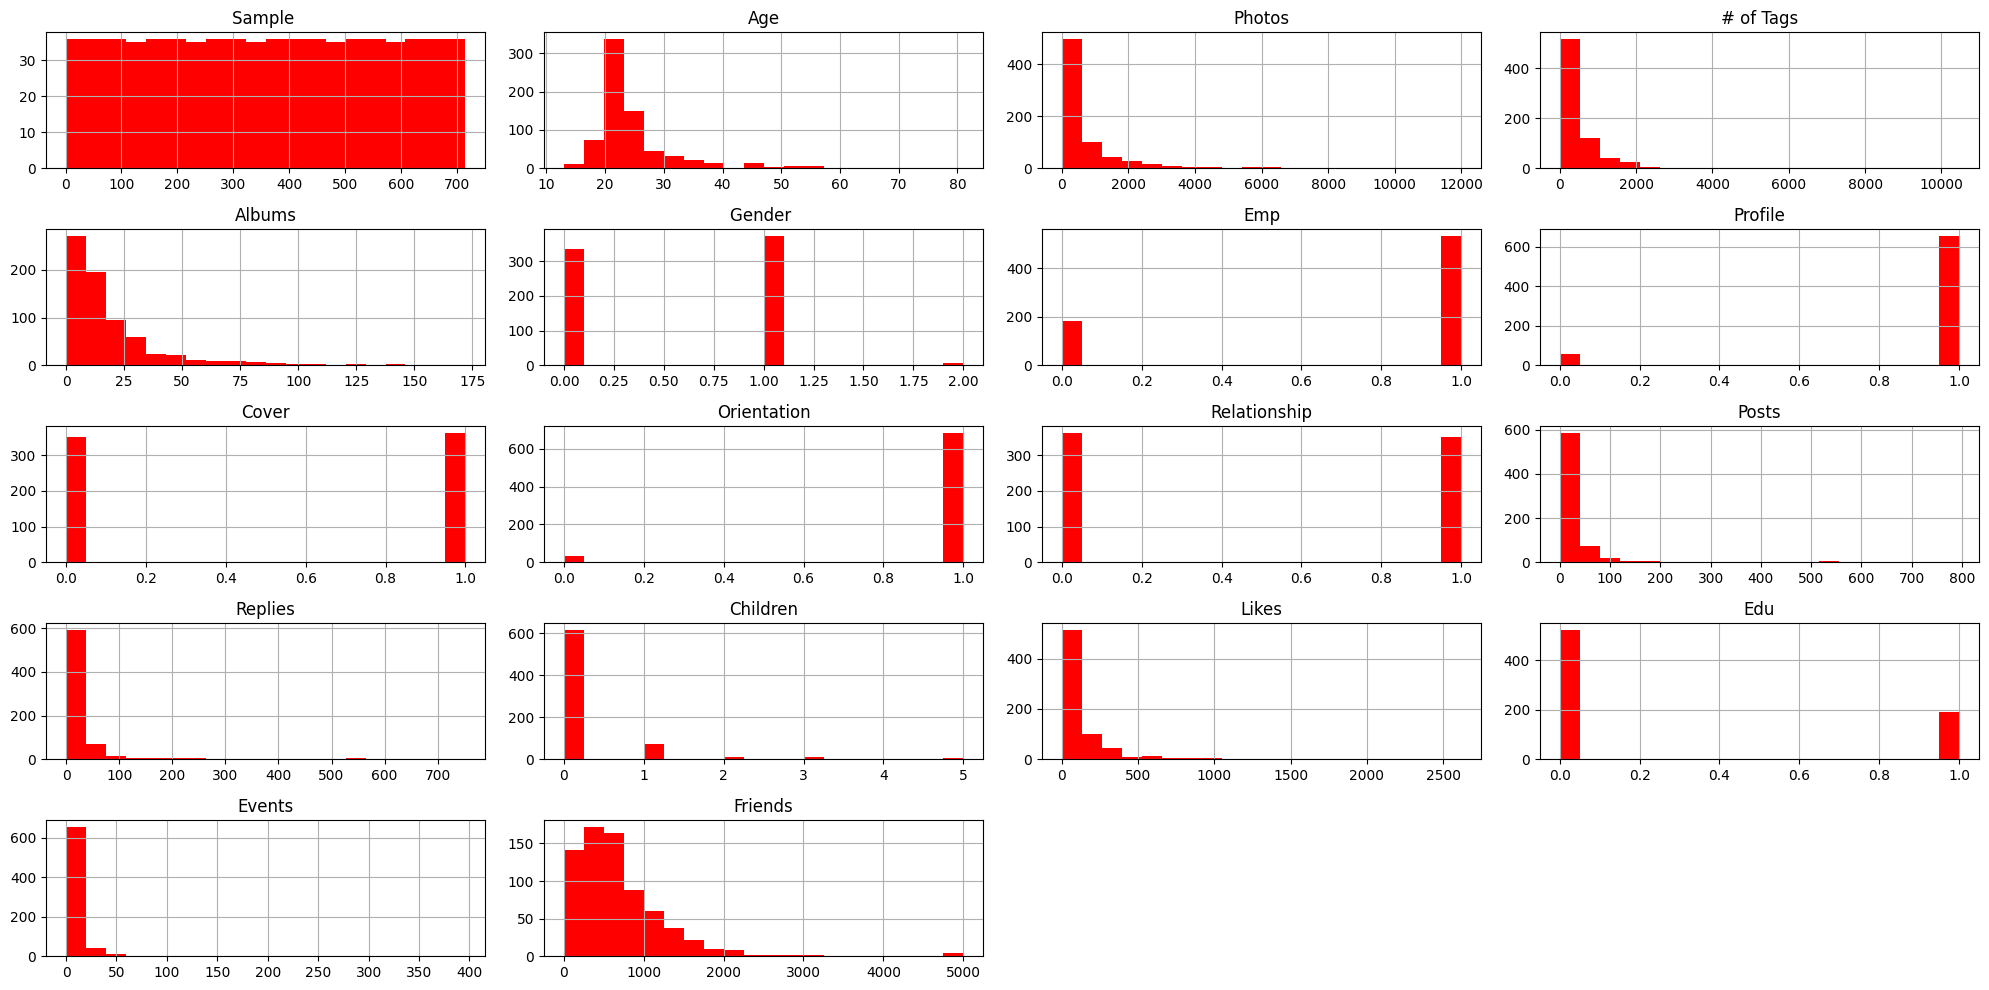

In [26]:
# 4) Data Visz/Data Visualization of Facebook Analytics
# Histograms for numerical columns
num_cols = ["Age", "Gender ", "Photos", "# of Tags", "Albums", "Posts", "Replies", "Likes", "Friends"]
plt.figure(figsize=(15, 10))
df.hist(bins=20, figsize=(20, 10), color="red")
plt.tight_layout()
plt.savefig("histograms.png")
for col in num_cols:
    plt.figure(figsize=(15, 10))
    sns.histplot(df[col], bins=20, kde=True, color="black")
    plt.title(f"Histogram of {col.strip()}")
    plt.xlabel(col.strip())
    plt.ylabel("Frequency")
    plt.savefig(f"histogram_{col.strip()}.png")
    plt.close()


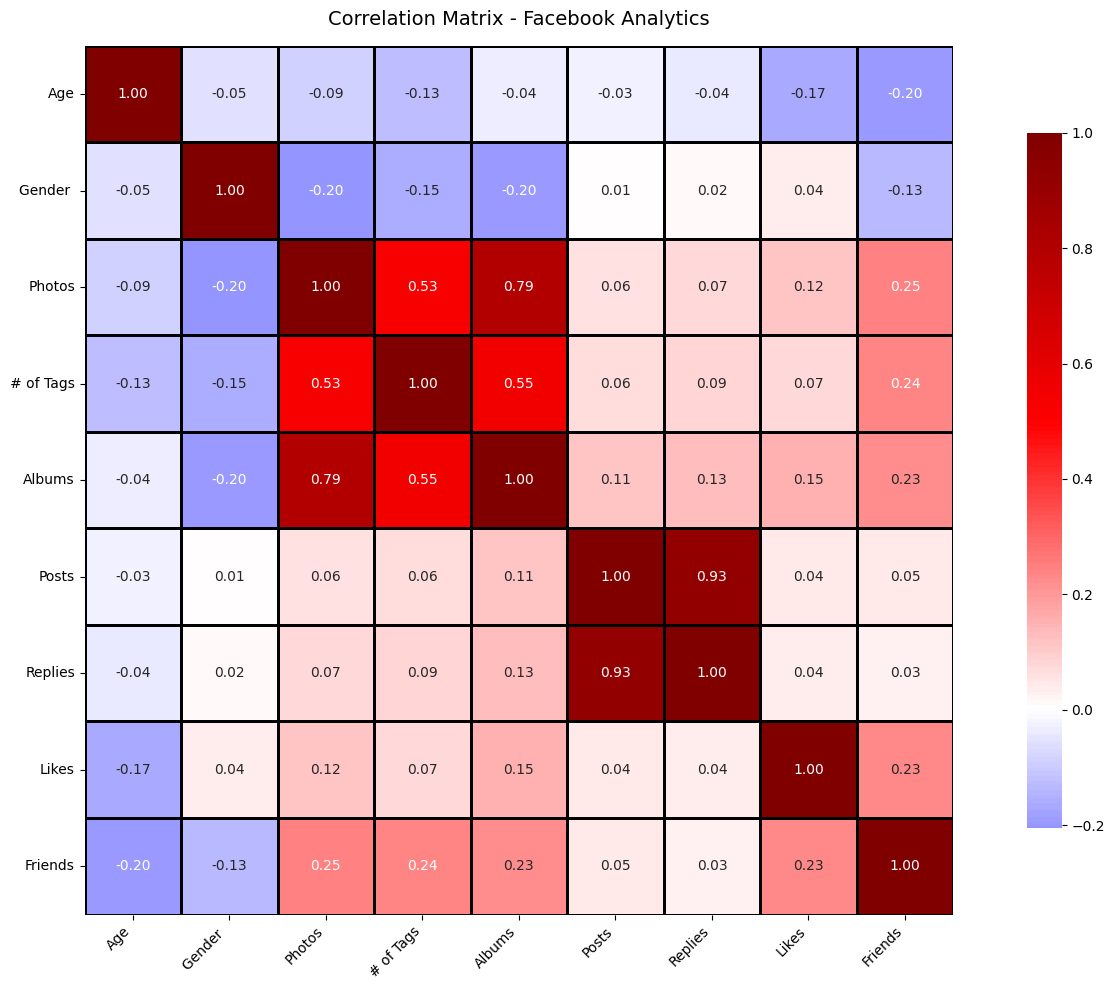

In [30]:
plt.figure(figsize=(15, 10))

corr_matrix = df[num_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="seismic",
    center=0,
    square=True,
    linewidths=0.8,
    linecolor="black",
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix - Facebook Analytics", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()
plt.close()

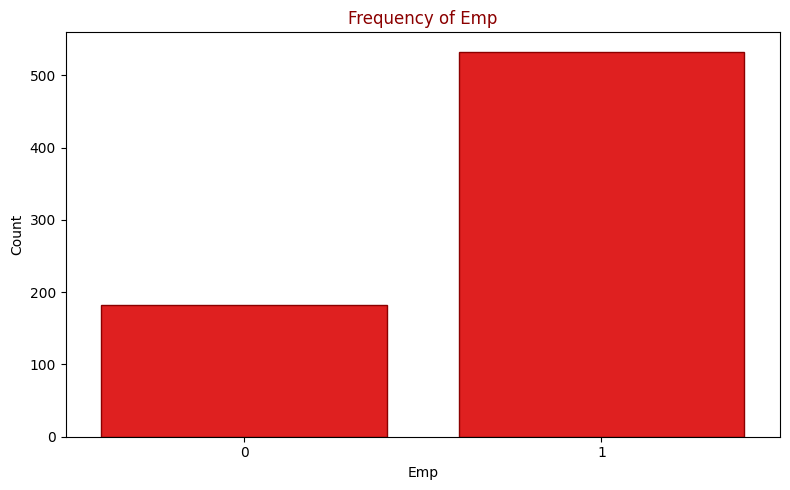

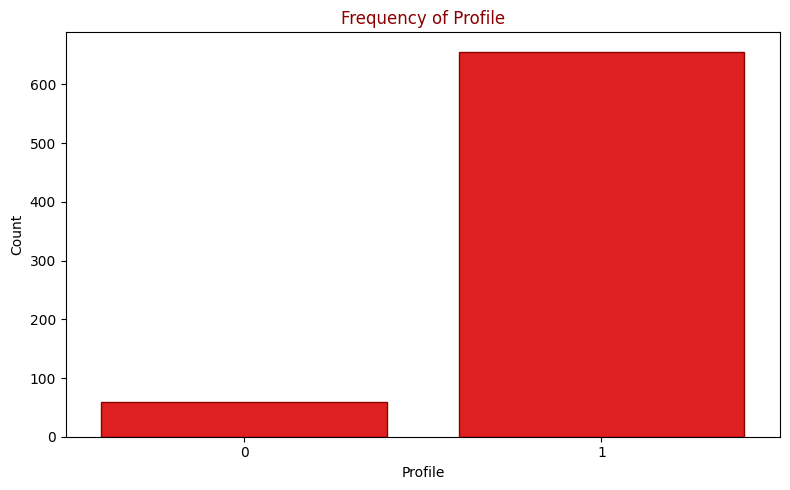

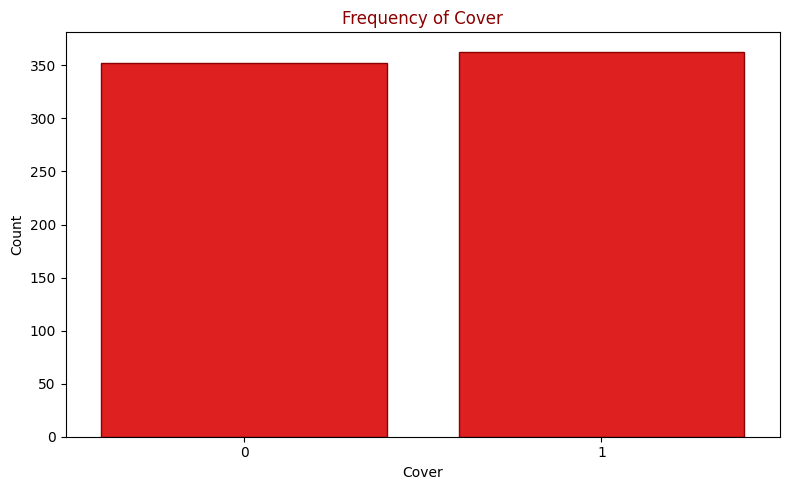

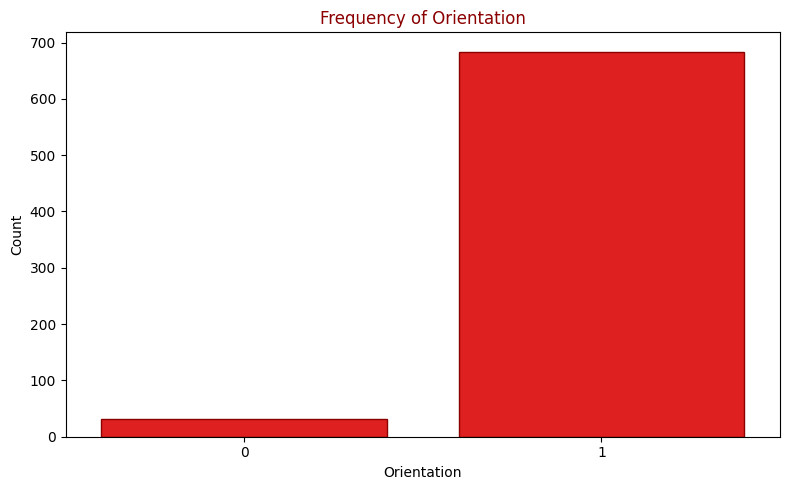

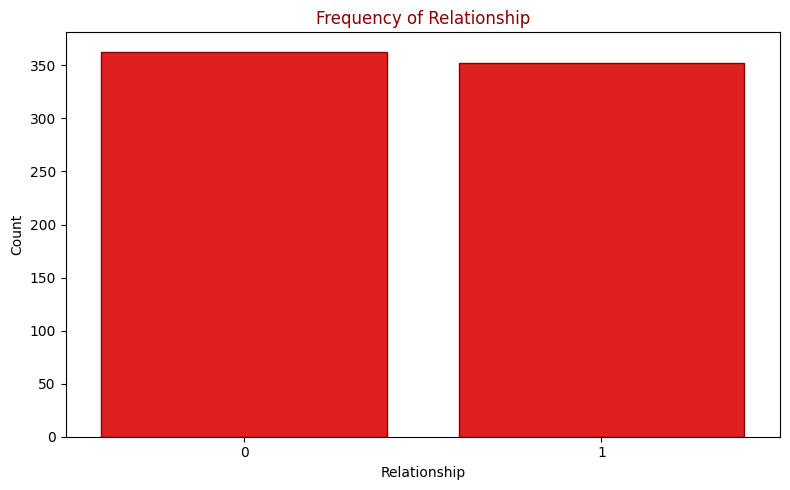

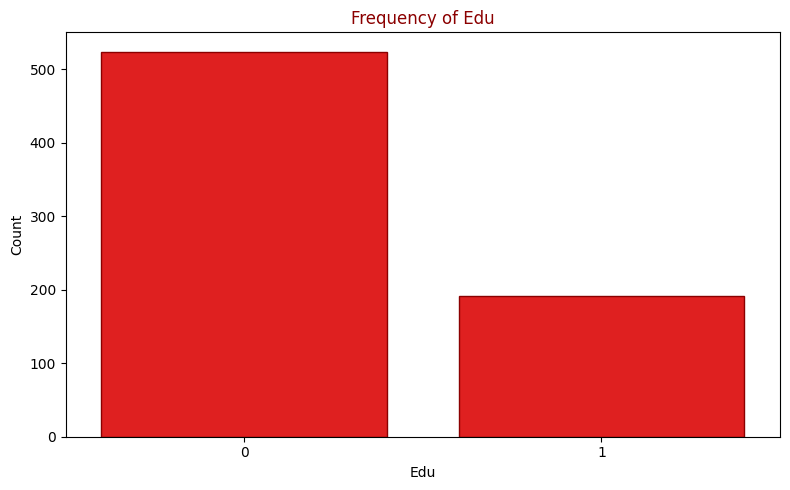

In [34]:
#Frequency plot for categorical / binary data
binary_cols = [col for col in df.columns if df[col].nunique() <= 2]

for i, col in enumerate(binary_cols[:6], 1):
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df[col], color="red", edgecolor="darkred")
    plt.xlabel(col.strip())
    plt.ylabel("Count")
    plt.title(f"Frequency of {col.strip()}", color="darkred")
    plt.tight_layout()
    plt.savefig(f"frequency_{col.strip()}.png")
    plt.show()
    plt.close()

In [45]:
import base64
import pandas as pd

def encode_image(image_path):
    with open(image_path, "rb") as img:
        return base64.b64encode(img.read()).decode("utf-8")

output_file = "Lab2Assignment_HTML_Suyodhannan S Nair.html"

with open(output_file, "w", encoding="utf-8") as f:
    f.write("<html><head><title>Facebook Friends Dataset Analysis</title></head><body>")

    f.write("<h1>Facebook Friends Dataset Analysis</h1>")

    # Section 1
    f.write("<h2>1. Data Access Comparison</h2>")
    f.write(compar.to_html(border=1))

    # Section 2
    f.write("<h2>2. Data Examination</h2>")

    f.write("<h3>Column Names</h3>")
    f.write(pd.DataFrame(columns, columns=["Columns"]).to_html(index=False))

    f.write("<h3>Head Rows</h3>")
    f.write(head_rows.to_html())

    f.write("<h3>Tail Rows</h3>")
    f.write(tail_rows.to_html())

    dtypes = df.dtypes
    missing = df.isnull().sum()

    f.write("<h3>Data Types</h3>")
    f.write(dtypes.to_frame(name="Data Type").to_html())

    f.write("<h3>Missing Values</h3>")
    f.write(missing.to_frame(name="Missing Count").to_html())

    # Section 3
    f.write("<h2>3. Descriptive Statistics</h2>")
    f.write(desc.to_html())

    # Section 4
    f.write("<h2>4. Data Visualization</h2>")

    # Embed Histograms
    f.write("<h3>Histograms</h3>")
    hist_base64 = encode_image("histograms.png")
    f.write(f"<img src='data:image/png;base64,{hist_base64}' width='700'><br><br>")

    # Embed Heatmap
    f.write("<h3>Correlation Heatmap</h3>")
    heat_base64 = encode_image("correlation_heatmap.png")
    f.write(f"<img src='data:image/png;base64,{heat_base64}' width='700'><br><br>")

    # Embed Frequency Plots
    f.write("<h3>Frequency Plots</h3>")
    for col in binary_cols[:6]:
        img_name = f"frequency_{col.strip()}.png"
        img_base64 = encode_image(img_name)
        f.write(f"<p><img src='data:image/png;base64,{img_base64}' width='600'></p>")

    f.write("</body></html>")

print("Analysis complete.")
print(f"Results saved to {output_file}")

Analysis complete.
Results saved to Lab2Assignment_HTML_Suyodhannan S Nair.html
